Where does the model fail, and on which types of firms?

What we will analyze

Error vs Firm Size

Error by Sign of Target (growth vs decline)

Error by Time Buckets

Worst-case errors (tail risk)

In [ ]:
import os
from pathlib import Path
import pandas as pd
from zenml.client import Client

client = Client()
latest_run = client.get_pipeline("training").last_run
# Paths coming from ZenML feature_engineering_step
val_fe_path  = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
test_fe_path = latest_run.steps["feature_engineering_step"].outputs["output_2"][0].load()

print("Raw val_fe_path:", val_fe_path)
print("Raw test_fe_path:", test_fe_path)
print("CWD:", os.getcwd())

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [
        Path(p),
        Path("..") / p,
        Path("..") / ".." / p,
        Path("..") / ".." / ".." / p,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p} (tried {len(candidates)} candidates)")

val_fe_path_resolved = resolve_existing(val_fe_path)
test_fe_path_resolved = resolve_existing(test_fe_path)

print("Resolved val_fe_path:", val_fe_path_resolved)
print("Resolved test_fe_path:", test_fe_path_resolved)
df_eval = pd.read_parquet(val_fe_path_resolved).copy()
df_eval["end"] = pd.to_datetime(df_eval["end"], errors="coerce")

print("df_eval shape:", df_eval.shape)
display(df_eval.head(3))


Raw val_fe_path: ./data/interim/val_fe.parquet ./data/interim/val_fe.parquet
Raw test_fe_path: ./data/interim/test_fe.parquet ./data/interim/test_fe.parquet
CWD: d:\balance-sheet-ml\notebooks d:\balance-sheet-ml\notebooks
Resolved val_fe_path: ..\data\interim\val_fe.parquet ..\data\interim\val_fe.parquet
Resolved test_fe_path: ..\data\interim\test_fe.parquet ..\data\interim\test_fe.parquet
df_eval shape: (9337, 157) (9337, 157)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,...,wc_to_assets_rollmean4,wc_to_assets_rollstd4,debt_to_assets_delta1,debt_to_assets_pct1,debt_to_assets_rollmean4,debt_to_assets_rollstd4,debt_to_equity_delta1,debt_to_equity_pct1,debt_to_equity_rollmean4,debt_to_equity_rollstd4
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,5.452000e+08,1.131300e+09,NaN,2.859100e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000001800,2025-03-31,8.144800e+10,2.315300e+10,NaN,3.263700e+10,1.300400e+10,NaN,4.881100e+10,8.144800e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0000001961,2023-12-31,2.654010e+05,2.654010e+05,NaN,3.407564e+06,3.407564e+06,NaN,-3.142163e+06,2.654010e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
import os
from pathlib import Path
from zenml.client import Client

client = Client()
latest_run = client.get_pipeline("training").last_run

# Model path from train_tree_step
model_path = latest_run.steps["train_tree_step"].outputs["output_0"][0].load()

print("Raw model_path:", model_path)
print("CWD:", os.getcwd())

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [
        Path(p),
        Path("..") / p,
        Path("..") / ".." / p,
        Path("..") / ".." / ".." / p,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p}")

model_path_resolved = resolve_existing(model_path)
print("Resolved model_path:", model_path_resolved)


Raw model_path: data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib
CWD: d:\balance-sheet-ml\notebooks d:\balance-sheet-ml\notebooks
Resolved model_path: ..\data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib ..\data\interim\models\hgb_y_Assets_it900_lr0.03_d6.joblib


In [12]:
import joblib
import numpy as np

bundle = joblib.load(model_path_resolved)

model = bundle["model"]
FEATURES = bundle["features"]
TARGET = bundle["target"]

X_val = df_eval[FEATURES]
y_true = df_eval[TARGET]

y_pred = model.predict(X_val)

df_eval["y_pred"] = y_pred
df_eval["residual"] = y_true - y_pred
df_eval["abs_error"] = np.abs(df_eval["residual"])

df_eval[["cik", "end", TARGET, "y_pred", "residual", "abs_error"]].head()


,cik,end,y_Assets,y_pred,residual,abs_error
0,0000001750,2025-02-28,0.003434,0.113805,-0.110371,0.110371
1,0000001800,2025-03-31,0.000418,-0.038138,0.038556,0.038556
2,0000001961,2023-12-31,1.708563,0.372468,1.336095,1.336095
3,0000002034,2018-06-30,0.007634,0.033154,-0.025521,0.025521
4,0000002488,2025-03-29,0.033020,0.004299,0.028720,0.028720


In [13]:
# Notebook 06 – Cell 1: sanity check

required_cols = [
    "cik", "end", "y_Assets", "y_pred", "residual", "abs_error"
]

missing = [c for c in required_cols if c not in df_eval.columns]
print("Missing columns:", missing)

print("Rows:", len(df_eval))
display(df_eval.head(5))


Missing columns: [] []
Rows: 9337 9337


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,...,debt_to_assets_pct1,debt_to_assets_rollmean4,debt_to_assets_rollstd4,debt_to_equity_delta1,debt_to_equity_pct1,debt_to_equity_rollmean4,debt_to_equity_rollstd4,y_pred,residual,abs_error
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,5.452000e+08,1.131300e+09,NaN,2.859100e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.113805,-0.110371,0.110371
1,0000001800,2025-03-31,8.144800e+10,2.315300e+10,NaN,3.263700e+10,1.300400e+10,NaN,4.881100e+10,8.144800e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.038138,0.038556,0.038556
2,0000001961,2023-12-31,2.654010e+05,2.654010e+05,NaN,3.407564e+06,3.407564e+06,NaN,-3.142163e+06,2.654010e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.372468,1.336095,1.336095
3,0000002034,2018-06-30,7.670240e+08,5.026270e+08,NaN,6.717390e+08,3.025180e+08,NaN,9.528500e+07,7.670240e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033154,-0.025521,0.025521
4,0000002488,2025-03-29,7.155000e+10,2.159500e+10,NaN,1.366900e+10,7.703000e+09,NaN,5.788100e+10,7.155000e+10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004299,0.028720,0.028720


In [14]:
# Notebook 06 – Cell 2: firm size buckets

size_col = "Assets_lag1" if "Assets_lag1" in df_eval.columns else "Assets"

df_eval["log_size"] = np.log10(df_eval[size_col].clip(lower=1))

# Create size buckets
df_eval["size_bucket"] = pd.qcut(
    df_eval["log_size"],
    q=5,
    labels=["XS", "S", "M", "L", "XL"]
)

df_eval.groupby("size_bucket")[["abs_error", "residual"]].agg(
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: np.sqrt(np.mean(x**2))),
    count=("residual", "count"),
)


C:\Users\PC\AppData\Local\Temp\ipykernel_12996\1832176660.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eval.groupby("size_bucket")[["abs_error", "residual"]].agg(


,mae,rmse,count
size_bucket,,,
XS,0.647821,0.943914,1868
S,0.319307,0.565096,1867
M,0.179028,0.373672,1867
L,0.131808,0.254898,1867
XL,0.095580,0.187034,1868


<Figure size 800x400 with 0 Axes>

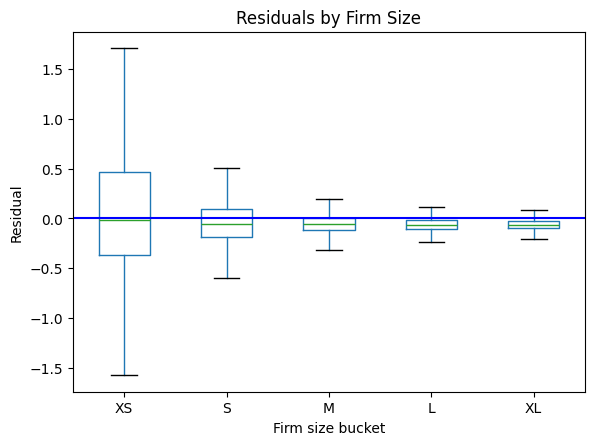

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df_eval.boxplot(
    column="residual",
    by="size_bucket",
    grid=False,
    showfliers=False,
)
plt.axhline(0, color="blue")
plt.title("Residuals by Firm Size")
plt.suptitle("")
plt.xlabel("Firm size bucket")
plt.ylabel("Residual")
plt.show()


In [16]:
# Notebook 06 – Cell 4

df_eval["direction"] = np.where(
    df_eval["y_Assets"] >= 0, "Growth", "Decline"
)

df_eval.groupby("direction")[["abs_error", "residual"]].agg(
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: np.sqrt(np.mean(x**2))),
    count=("residual", "count"),
)


,mae,rmse,count
direction,,,
Decline,0.266838,0.492995,4600
Growth,0.282393,0.579335,4737


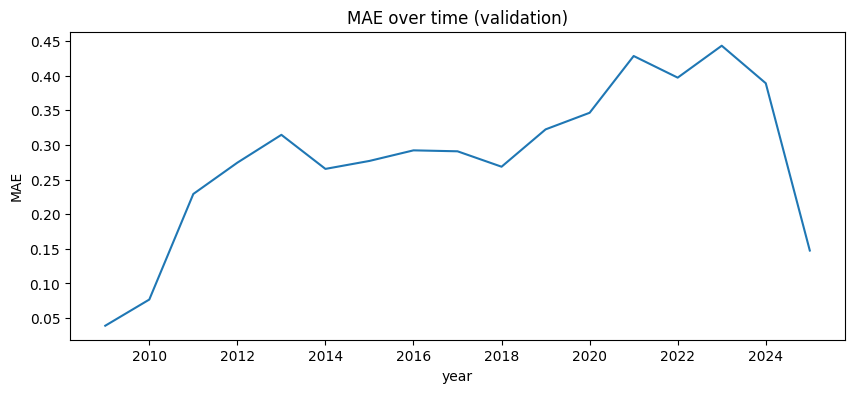

In [17]:
# Notebook 06 – Cell 5

df_eval["year"] = df_eval["end"].dt.year

df_eval.groupby("year")["abs_error"].mean().plot(
    figsize=(10, 4),
    title="MAE over time (validation)",
)
plt.ylabel("MAE")
plt.show()


In [18]:
# Notebook 06 – Cell 6

df_eval.sort_values("abs_error", ascending=False).head(20)[
    ["cik", "end", "y_Assets", "y_pred", "residual", "abs_error"]
]


,cik,end,y_Assets,y_pred,residual,abs_error
5554,0001418115,2021-03-31,-3.000000,1.803752,-4.803752,4.803752
7450,0001571636,2018-12-31,2.829655,-1.351486,4.181141,4.181141
4966,0001373853,2013-08-31,-2.740840,1.396662,-4.137502,4.137502
4903,0001368761,2015-09-30,-2.240710,1.703436,-3.944146,3.944146
7599,0001582249,2023-06-30,3.000000,-0.610462,3.610462,3.610462
8118,0001635748,2019-12-31,3.000000,-0.551485,3.551485,3.551485
8257,0001655971,2019-12-31,-3.000000,0.517394,-3.517394,3.517394
980,0000724742,2024-03-31,-3.000000,0.426827,-3.426827,3.426827
3999,0001228386,2016-12-31,-1.945910,1.264732,-3.210642,3.210642
5949,0001448705,2024-09-30,2.465743,-0.654504,3.120247,3.120247
